In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df = pd.read_csv("D:/Projects/Customer_Churn/data/telco_churn.csv")
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.shape


(7043, 21)

In [5]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [7]:
pd.to_numeric(df["TotalCharges"],errors="coerce").isna().sum()

np.int64(11)

In [8]:
df.loc[pd.to_numeric(df["TotalCharges"],errors = "coerce").isna(), ["customerID","tenure","MonthlyCharges","TotalCharges","Churn"]]

,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


In [9]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"],errors = "coerce")

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [11]:
df["TotalCharges"].isna().sum()

np.int64(11)

In [12]:
df.loc[df["TotalCharges"].isna(),["tenure","MonthlyCharges","TotalCharges"]]

,tenure,MonthlyCharges,TotalCharges
488,0,52.55,NaN
753,0,20.25,NaN
936,0,80.85,NaN
1082,0,25.75,NaN
1340,0,56.05,NaN
3331,0,19.85,NaN
3826,0,25.35,NaN
4380,0,20.00,NaN
5218,0,19.70,NaN
6670,0,73.35,NaN


In [13]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)

In [14]:
df["TotalCharges"].isna().sum()

np.int64(0)

In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df["customerID"].duplicated().sum()

np.int64(0)

In [17]:
for col in df.select_dtypes(include = "str").columns:
    print(f"{col}:{df[col].nunique()} unique values")

    if df[col].nunique()<20:
        print(df[col].unique())
    print("\n")

    



customerID:7043 unique values


gender:2 unique values
<StringArray>
['Female', 'Male']
Length: 2, dtype: str


Partner:2 unique values
<StringArray>
['Yes', 'No']
Length: 2, dtype: str


Dependents:2 unique values
<StringArray>
['No', 'Yes']
Length: 2, dtype: str


PhoneService:2 unique values
<StringArray>
['No', 'Yes']
Length: 2, dtype: str


MultipleLines:3 unique values
<StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str


InternetService:3 unique values
<StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str


OnlineSecurity:3 unique values
<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str


OnlineBackup:3 unique values
<StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str


DeviceProtection:3 unique values
<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str


TechSupport:3 unique values
<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str


StreamingTV:3 unique values
<S

In [18]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [19]:
df["Churn"].value_counts(normalize=True)*100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

In [20]:
df.select_dtypes(include="number").columns

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='str')

In [21]:
df[["tenure","MonthlyCharges","TotalCharges"]].describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304
std,24.559481,30.090047,2266.794470
min,0.000000,18.250000,0.000000
25%,9.000000,35.500000,398.550000
50%,29.000000,70.350000,1394.550000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


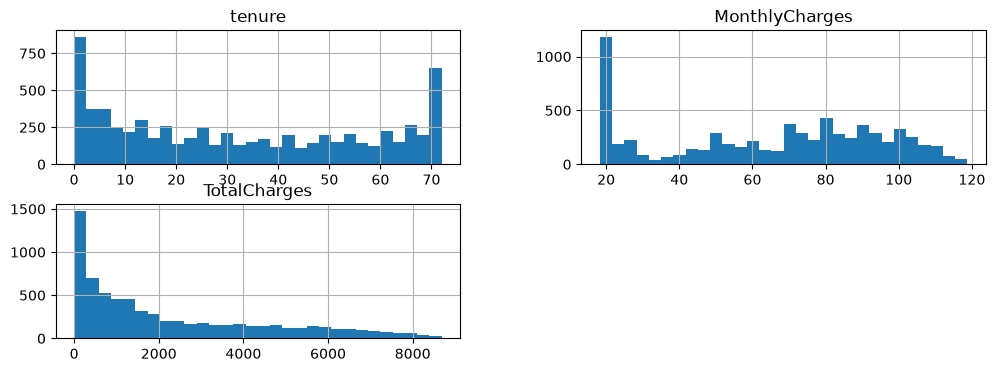

In [22]:
df[["tenure","MonthlyCharges","TotalCharges"]].hist(
    bins = 30,
    figsize = (12,4)
)

plt.tight_layout
plt.show()

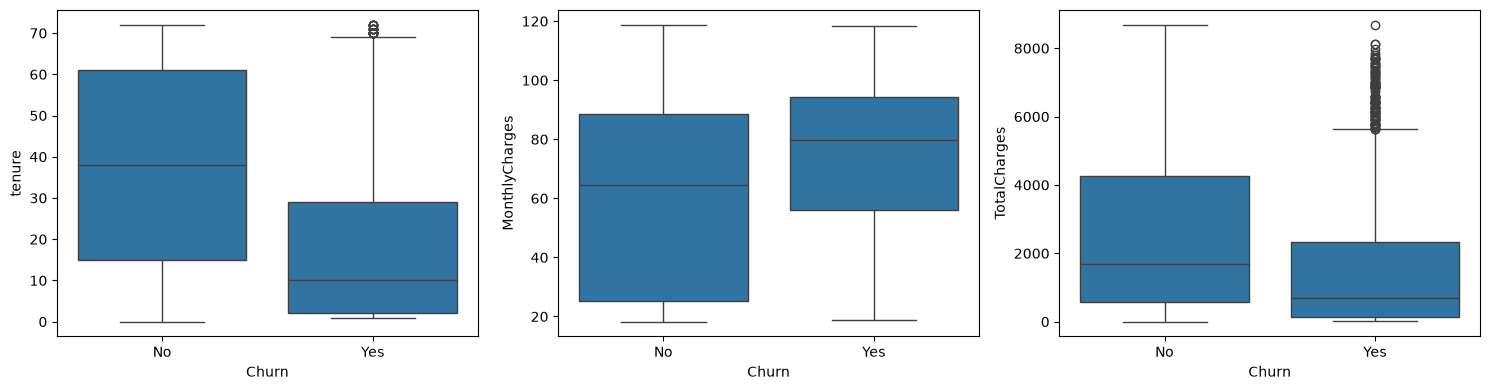

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.boxplot(data=df, x="Churn", y="tenure", ax=axes[0])
sns.boxplot(data=df, x="Churn", y="MonthlyCharges", ax=axes[1])
sns.boxplot(data=df, x="Churn", y="TotalCharges", ax=axes[2])

plt.tight_layout()
plt.show()

In [24]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize = "index"

) *100

print(contract_churn)

Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.730482  11.269518
Two year        97.168142   2.831858


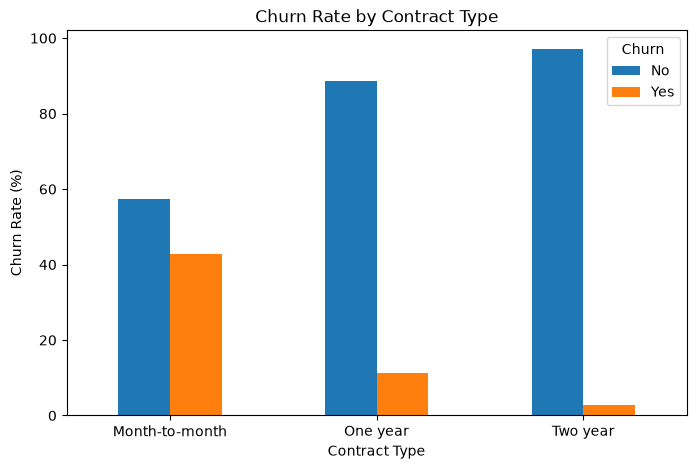

In [25]:
contract_churn.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.ylabel("Churn Rate (%)")
plt.xlabel("Contract Type")
plt.title("Churn Rate by Contract Type")
plt.xticks(rotation=0)
plt.show()

In [26]:
categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    if col not in ["customerID", "Churn"]:
        churn_rate = pd.crosstab(
            df[col],
            df["Churn"],
            normalize="index"
        )["Yes"] * 100
        
        print(f"\n{col}")
        print(churn_rate.sort_values(ascending=False))


gender
gender
Female    26.920872
Male      26.160338
Name: Yes, dtype: float64

Partner
Partner
No     32.957979
Yes    19.664903
Name: Yes, dtype: float64

Dependents
Dependents
No     31.279140
Yes    15.450237
Name: Yes, dtype: float64

PhoneService
PhoneService
Yes    26.709637
No     24.926686
Name: Yes, dtype: float64

MultipleLines
MultipleLines
Yes                 28.609896
No                  25.044248
No phone service    24.926686
Name: Yes, dtype: float64

InternetService
InternetService
Fiber optic    41.892765
DSL            18.959108
No              7.404980
Name: Yes, dtype: float64

OnlineSecurity
OnlineSecurity
No                     41.766724
Yes                    14.611194
No internet service     7.404980
Name: Yes, dtype: float64

OnlineBackup
OnlineBackup
No                     39.928756
Yes                    21.531494
No internet service     7.404980
Name: Yes, dtype: float64

DeviceProtection
DeviceProtection
No                     39.127625
Yes              

C:\Users\sushil\AppData\Local\Temp\ipykernel_14280\3829233130.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include="object").columns


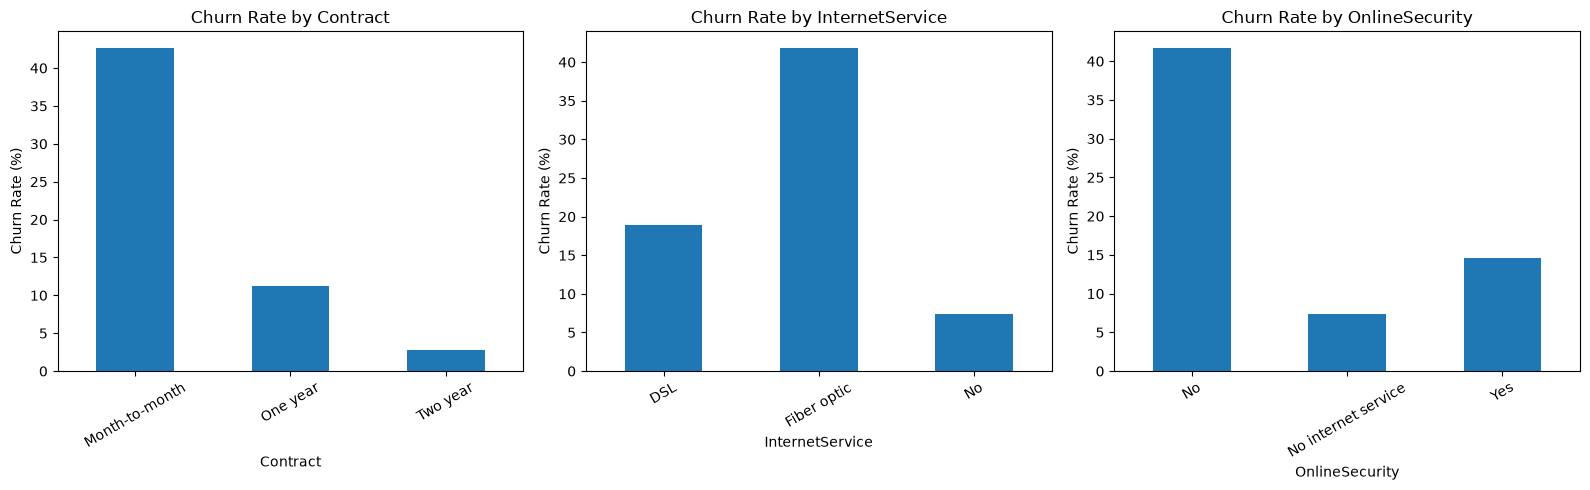

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

features = ["Contract", "InternetService", "OnlineSecurity"]

for ax, col in zip(axes, features):
    churn_rate = pd.crosstab(
        df[col],
        df["Churn"],
        normalize="index"
    )["Yes"] * 100
    
    churn_rate.plot(kind="bar", ax=ax)
    
    ax.set_title(f"Churn Rate by {col}")
    ax.set_ylabel("Churn Rate (%)")
    ax.set_xlabel(col)
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

In [28]:
def plot_churn_rate(df, features, ncols=3):
    nrows = (len(features) + ncols - 1) // ncols
    
    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(16, 5 * nrows)
    )
    
    axes = np.array(axes).flatten()

    for ax, col in zip(axes, features):
        churn_rate = (
            pd.crosstab(
                df[col],
                df["Churn"],
                normalize="index"
            )["Yes"] * 100
        )

        churn_rate.plot(kind="bar", ax=ax)

        ax.set_title(f"Churn Rate by {col}")
        ax.set_xlabel(col)
        ax.set_ylabel("Churn Rate (%)")
        ax.tick_params(axis="x", rotation=20)

    for ax in axes[len(features):]:
        ax.set_visible(False)

    plt.tight_layout()
    plt.show()

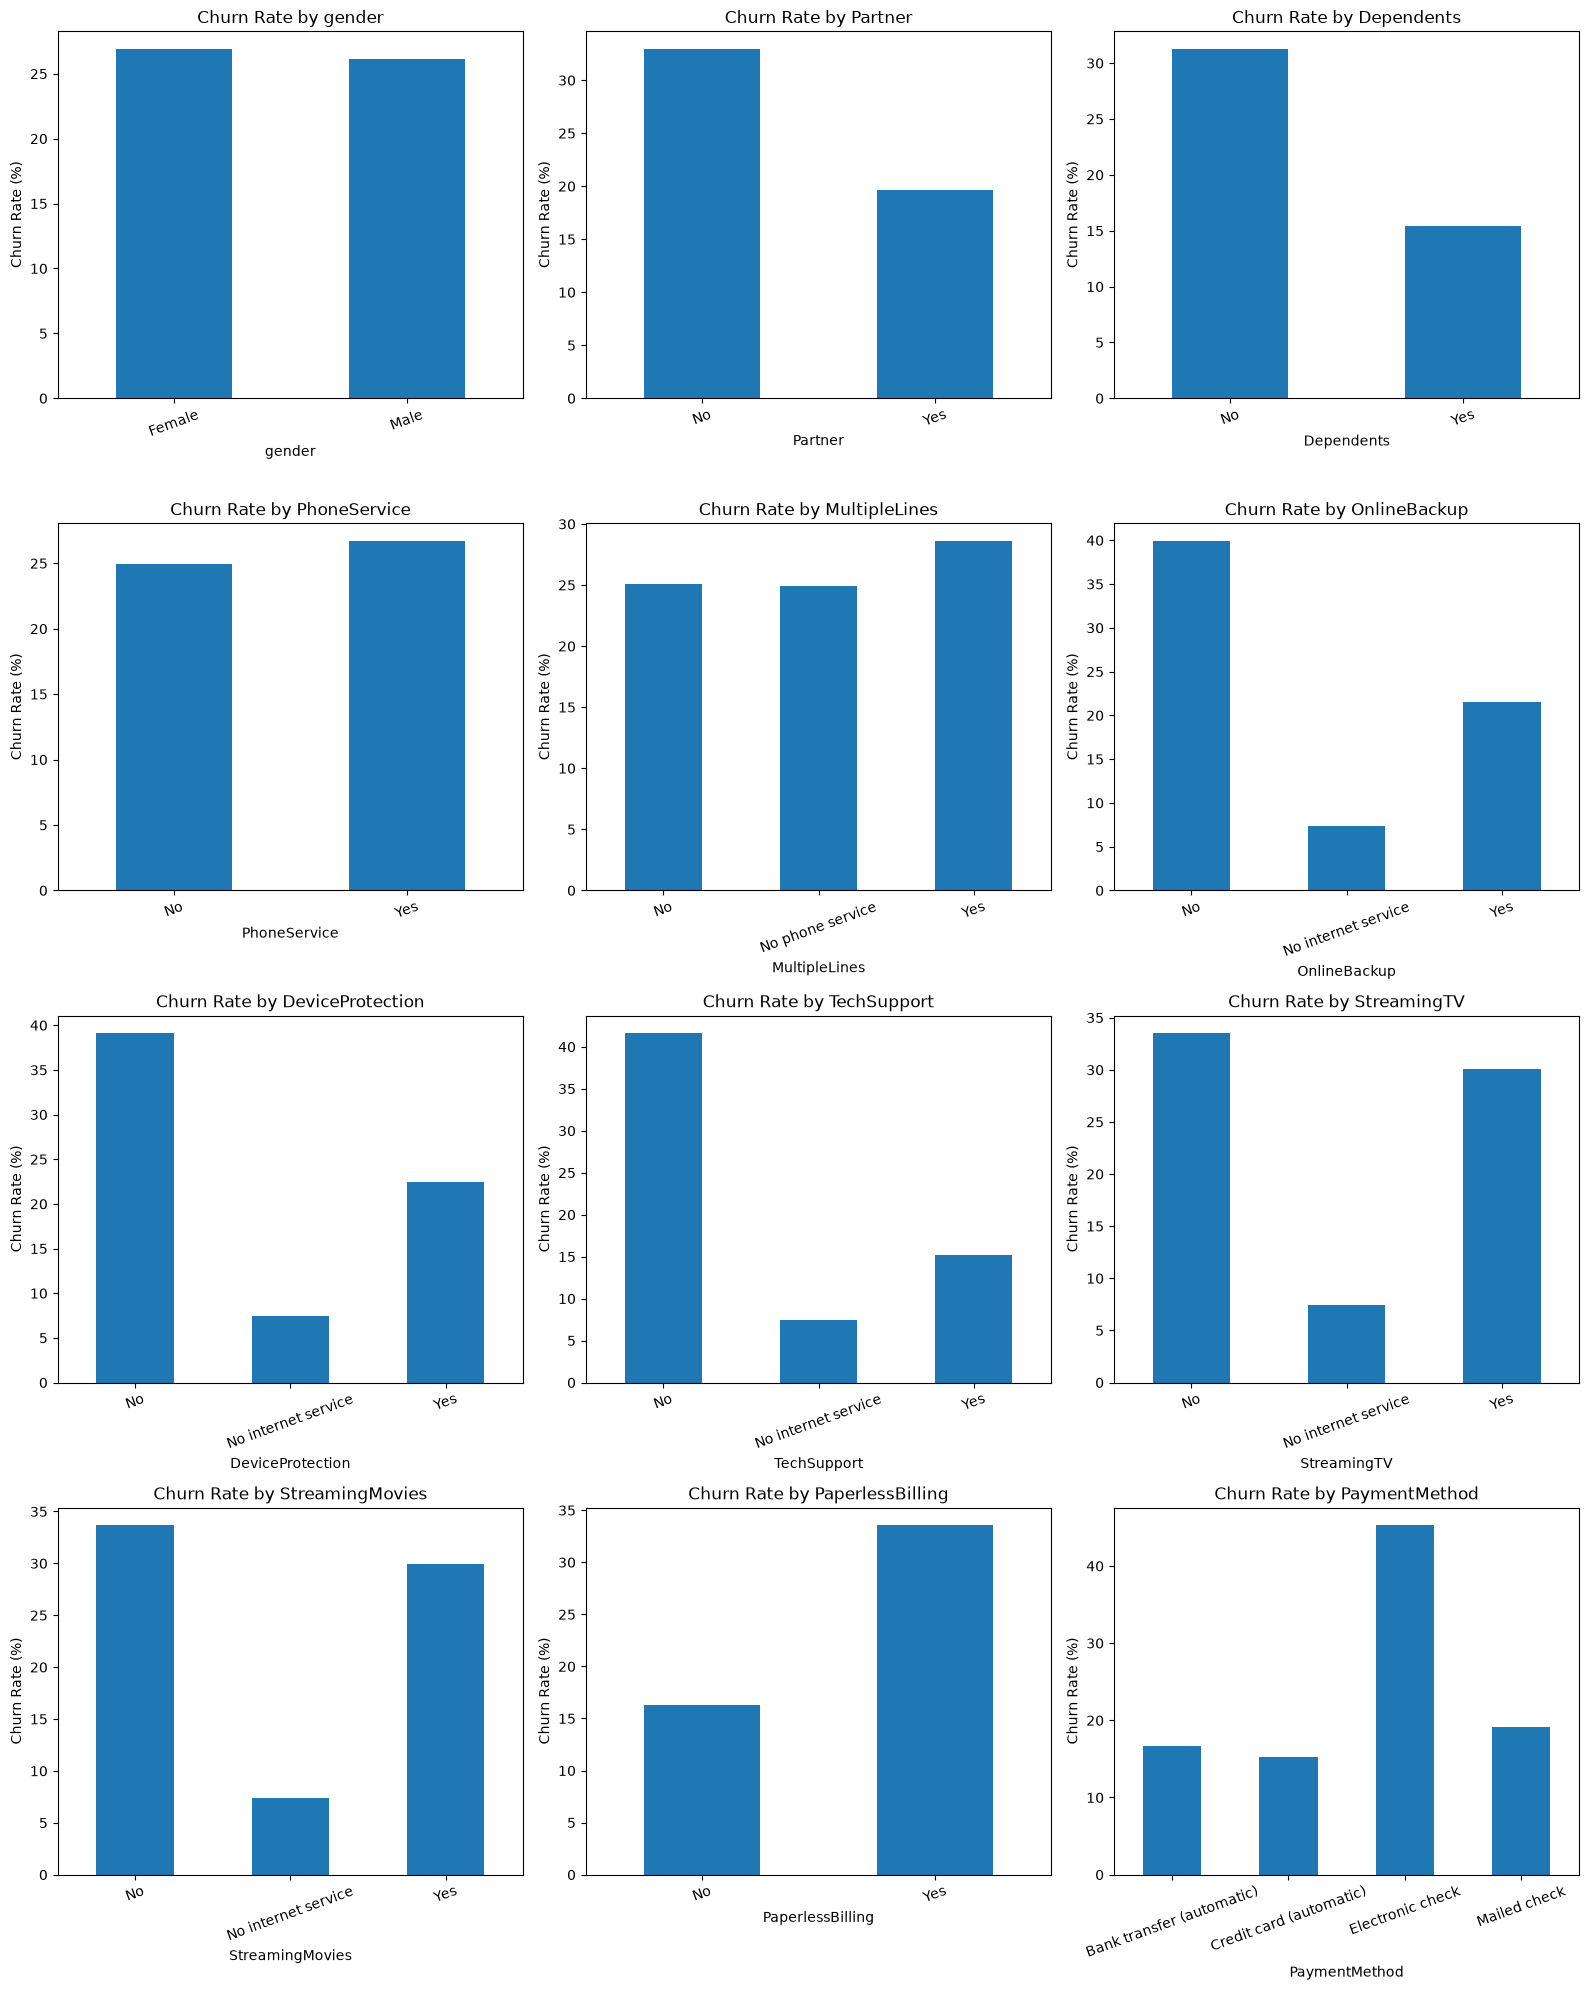

In [29]:
features = [
    "gender",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "PaperlessBilling",
    "PaymentMethod"
]

plot_churn_rate(df, features)

In [30]:
df[["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"]].corr()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
SeniorCitizen,1.000000,0.016567,0.220173,0.103006
tenure,0.016567,1.000000,0.247900,0.826178
MonthlyCharges,0.220173,0.247900,1.000000,0.651174
TotalCharges,0.103006,0.826178,0.651174,1.000000


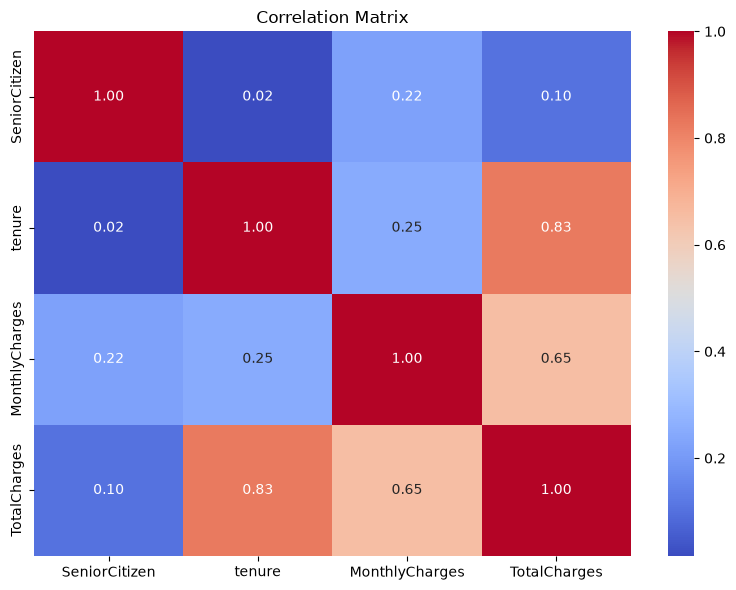

In [31]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    df[["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"]].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In [32]:
Q1 = df["MonthlyCharges"].quantile(0.25)
Q3 = df["MonthlyCharges"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

Q1: 35.5
Q3: 89.85
IQR: 54.349999999999994
Lower bound: -46.02499999999999
Upper bound: 171.375


In [33]:
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ((df[col] < lower) | (df[col] > upper)).sum()

    print(f"{col}: {outliers} potential outliers")

tenure: 0 potential outliers
MonthlyCharges: 0 potential outliers
TotalCharges: 0 potential outliers


In [35]:
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    print(col)
    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)
    print()

tenure
Q1: 9.0
Q3: 55.0
IQR: 46.0

MonthlyCharges
Q1: 35.5
Q3: 89.85
IQR: 54.349999999999994

TotalCharges
Q1: 398.55
Q3: 3786.6
IQR: 3388.0499999999997



In [37]:
important_features = [
    "Contract",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "PaymentMethod",
    "PaperlessBilling"
]

for col in important_features:
    print(f"\n--- {col} ---")
    print(
        pd.crosstab(
            df[col],
            df["Churn"],
            normalize="index"
        )["Yes"].mul(100).round(2)
    )


--- Contract ---
Contract
Month-to-month    42.71
One year          11.27
Two year           2.83
Name: Yes, dtype: float64

--- InternetService ---
InternetService
DSL            18.96
Fiber optic    41.89
No              7.40
Name: Yes, dtype: float64

--- OnlineSecurity ---
OnlineSecurity
No                     41.77
No internet service     7.40
Yes                    14.61
Name: Yes, dtype: float64

--- OnlineBackup ---
OnlineBackup
No                     39.93
No internet service     7.40
Yes                    21.53
Name: Yes, dtype: float64

--- DeviceProtection ---
DeviceProtection
No                     39.13
No internet service     7.40
Yes                    22.50
Name: Yes, dtype: float64

--- TechSupport ---
TechSupport
No                     41.64
No internet service     7.40
Yes                    15.17
Name: Yes, dtype: float64

--- PaymentMethod ---
PaymentMethod
Bank transfer (automatic)    16.71
Credit card (automatic)      15.24
Electronic check             45.29
M

In [38]:
df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=[-1, 6, 12, 24, 48, 72],
    labels=["0-6", "7-12", "13-24", "25-48", "49-72"]
)

pd.crosstab(
    df["TenureGroup"],
    df["Churn"],
    normalize="index"
).mul(100).round(2)

Churn,No,Yes
TenureGroup,,
0-6,47.06,52.94
7-12,64.11,35.89
13-24,71.29,28.71
25-48,79.61,20.39
49-72,90.49,9.51


In [39]:
df.columns.tolist()

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn',
 'TenureGroup']

# Feature Engineering

In [40]:
df_model = df.copy()

In [41]:
service_cols = [
    "PhoneService",
    "MultipleLines",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

In [42]:
df_model["TotalServices"] = (
    df_model[service_cols]
    .eq("Yes")
    .sum(axis=1)
)

In [43]:
df_model["IsNewCustomer"] = (
    df_model["tenure"] <= 6
).astype(int)

In [44]:
df_model["LongTermContract"] = (
    df_model["Contract"].isin(["One year", "Two year"])
).astype(int)

In [45]:
df_model["AvgMonthlySpend"] = (
    df_model["TotalCharges"] /
    df_model["tenure"].replace(0, np.nan)
)

In [46]:
df_model["AvgMonthlySpend"] = (
    df_model["AvgMonthlySpend"]
    .fillna(df_model["MonthlyCharges"])
)

In [47]:
df_model["HasSupport"] = (
    df_model["TechSupport"] == "Yes"
).astype(int)

In [48]:
df_model["HasSecurity"] = (
    df_model["OnlineSecurity"] == "Yes"
).astype(int)

In [49]:
df_model["ChargePerTenureMonth"] = (
    df_model["TotalCharges"] /
    df_model["tenure"].replace(0, np.nan)
)

In [50]:
df_model["ChargePerTenureMonth"] = (
    df_model["ChargePerTenureMonth"]
    .fillna(df_model["MonthlyCharges"])
)

In [51]:
engineered_features = [
    "TotalServices",
    "IsNewCustomer",
    "LongTermContract",
    "AvgMonthlySpend",
    "HasSupport",
    "HasSecurity",
    "ChargePerTenureMonth"
]

df_model[engineered_features].head()

,TotalServices,IsNewCustomer,LongTermContract,AvgMonthlySpend,HasSupport,HasSecurity,ChargePerTenureMonth
0,1,1,0,29.850000,0,0,29.850000
1,3,0,1,55.573529,0,1,55.573529
2,3,1,0,54.075000,0,1,54.075000
3,3,0,1,40.905556,1,1,40.905556
4,1,1,0,75.825000,0,0,75.825000


In [52]:
df_model[engineered_features].describe()

,TotalServices,IsNewCustomer,LongTermContract,AvgMonthlySpend,HasSupport,HasSecurity,ChargePerTenureMonth
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,3.362914,0.210280,0.449808,64.762906,0.290217,0.286668,64.762906
std,2.062031,0.407536,0.497510,30.189796,0.453895,0.452237,30.189796
min,0.000000,0.000000,0.000000,13.775000,0.000000,0.000000,13.775000
25%,1.000000,0.000000,0.000000,35.935156,0.000000,0.000000,35.935156
50%,3.000000,0.000000,0.000000,70.337500,0.000000,0.000000,70.337500
75%,5.000000,0.000000,1.000000,90.174158,1.000000,1.000000,90.174158
max,8.000000,1.000000,1.000000,121.400000,1.000000,1.000000,121.400000


In [69]:
categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numeric_features = X.select_dtypes(
    include=["number"]
).columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numeric_features)

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TenureGroup']

Numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'TotalServices', 'IsNewCustomer', 'LongTermContract', 'AvgMonthlySpend', 'HasSupport', 'HasSecurity', 'ChargePerTenureMonth']


C:\Users\sushil\AppData\Local\Temp\ipykernel_14280\220346551.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(


In [53]:
print("Missing values:")
print(df_model[engineered_features].isna().sum())

print("\nInfinite values:")
print(
    np.isinf(
        df_model[engineered_features]
        .select_dtypes(include=np.number)
    ).sum()
)

Missing values:
TotalServices           0
IsNewCustomer           0
LongTermContract        0
AvgMonthlySpend         0
HasSupport              0
HasSecurity             0
ChargePerTenureMonth    0
dtype: int64

Infinite values:
TotalServices           0
IsNewCustomer           0
LongTermContract        0
AvgMonthlySpend         0
HasSupport              0
HasSecurity             0
ChargePerTenureMonth    0
dtype: int64


In [54]:
pd.crosstab(
    df_model["TotalServices"],
    df_model["Churn"],
    normalize="index"
)["Yes"].mul(100).round(2)

TotalServices
0    43.75
1    21.11
2    32.83
3    36.48
4    31.34
5    25.55
6    22.49
7    12.41
8     5.29
Name: Yes, dtype: float64

In [55]:
pd.crosstab(
    df_model["IsNewCustomer"],
    df_model["Churn"],
    normalize="index"
).mul(100).round(2)

Churn,No,Yes
IsNewCustomer,,
0,80.49,19.51
1,47.06,52.94


In [56]:
df_model[
    numeric_cols + engineered_features
].corr()

,tenure,MonthlyCharges,TotalCharges,TotalServices,IsNewCustomer,LongTermContract,AvgMonthlySpend,HasSupport,HasSecurity,ChargePerTenureMonth
tenure,1.000000,0.247900,0.826178,0.523600,-0.627442,0.645561,0.247234,0.324221,0.327203,0.247234
MonthlyCharges,0.247900,1.000000,0.651174,0.802322,-0.171897,-0.060165,0.996244,0.338304,0.296594,0.996244
TotalCharges,0.826178,0.651174,1.000000,0.795854,-0.486540,0.444255,0.651025,0.431883,0.411651,0.651025
TotalServices,0.523600,0.802322,0.795854,1.000000,-0.351903,0.282007,0.800366,0.584471,0.522362,0.800366
IsNewCustomer,-0.627442,-0.171897,-0.486540,-0.351903,1.000000,-0.418946,-0.171431,-0.207130,-0.214626,-0.171431
LongTermContract,0.645561,-0.060165,0.444255,0.282007,-0.418946,1.000000,-0.059102,0.285241,0.246679,-0.059102
AvgMonthlySpend,0.247234,0.996244,0.651025,0.800366,-0.171431,-0.059102,1.000000,0.338045,0.296915,1.000000
HasSupport,0.324221,0.338304,0.431883,0.584471,-0.207130,0.285241,0.338045,1.000000,0.354931,0.338045
HasSecurity,0.327203,0.296594,0.411651,0.522362,-0.214626,0.246679,0.296915,0.354931,1.000000,0.296915
ChargePerTenureMonth,0.247234,0.996244,0.651025,0.800366,-0.171431,-0.059102,1.000000,0.338045,0.296915,1.000000


# Preprossing

In [57]:
df_model.columns.tolist()

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn',
 'TenureGroup',
 'TotalServices',
 'IsNewCustomer',
 'LongTermContract',
 'AvgMonthlySpend',
 'HasSupport',
 'HasSecurity',
 'ChargePerTenureMonth']

In [58]:
X = df_model.drop(columns=["customerID", "Churn"])
y = df_model["Churn"].map({"No": 0, "Yes": 1})

In [59]:
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

X shape: (7043, 27)
y shape: (7043,)

Target distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64


In [60]:
categorical_features = X.select_dtypes(include="object").columns.tolist()
numeric_features = X.select_dtypes(exclude="object").columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numeric_features)

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'TenureGroup', 'TotalServices', 'IsNewCustomer', 'LongTermContract', 'AvgMonthlySpend', 'HasSupport', 'HasSecurity', 'ChargePerTenureMonth']


C:\Users\sushil\AppData\Local\Temp\ipykernel_14280\3576466923.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include="object").columns.tolist()


In [70]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [62]:
print("Training:", X_train.shape)
print("Testing :", X_test.shape)

print("\nTraining target:")
print(y_train.value_counts(normalize=True))

print("\nTesting target:")
print(y_test.value_counts(normalize=True))

Training: (5634, 27)
Testing : (1409, 27)

Training target:
Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64

Testing target:
Churn
0    0.734564
1    0.265436
Name: proportion, dtype: float64


In [71]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

In [72]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape :", X_test_processed.shape)

Processed training shape: (5634, 57)
Processed testing shape : (1409, 57)


In [73]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [74]:
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    print("Accuracy :", round(accuracy_score(y_test, y_pred), 4))
    print("Precision:", round(precision_score(y_test, y_pred), 4))
    print("Recall   :", round(recall_score(y_test, y_pred), 4))
    print("F1 Score :", round(f1_score(y_test, y_pred), 4))
    print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob), 4))

### Logistic Regression

In [75]:
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=2000,
        random_state=42
    ))
])

In [76]:
logistic_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](27,)","['gender','SeniorCitizen','Partner',...,'HasSupport','HasSecurity', 'ChargePerTenureMonth']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,27
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='

In [77]:
evaluate_model(
    logistic_model,
    X_test,
    y_test
)

Accuracy : 0.7963
Precision: 0.6505
Recall   : 0.5027
F1 Score : 0.5671
ROC-AUC  : 0.845


### Decision Tree

In [78]:
from sklearn.tree import DecisionTreeClassifier

decision_tree_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(
        max_depth=6,
        random_state=42
    ))
])

In [79]:
decision_tree_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](27,)","['gender','SeniorCitizen','Partner',...,'HasSupport','HasSecurity', 'ChargePerTenureMonth']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,27
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='

In [80]:
evaluate_model(
    decision_tree_model,
    X_test,
    y_test
)

Accuracy : 0.7899
Precision: 0.6364
Recall   : 0.4866
F1 Score : 0.5515
ROC-AUC  : 0.8338


### Random Forest

In [81]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        min_samples_split=5,
        random_state=42,
        n_jobs=-1
    ))
])

In [82]:
random_forest_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](27,)","['gender','SeniorCitizen','Partner',...,'HasSupport','HasSecurity', 'ChargePerTenureMonth']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,27
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='

In [83]:
evaluate_model(
    random_forest_model,
    X_test,
    y_test
)

Accuracy : 0.7991
Precision: 0.6574
Recall   : 0.508
F1 Score : 0.5732
ROC-AUC  : 0.8403


### Gradient Boosting

In [84]:
from sklearn.ensemble import GradientBoostingClassifier

gradient_boosting_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

In [85]:
gradient_boosting_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](27,)","['gender','SeniorCitizen','Partner',...,'HasSupport','HasSecurity', 'ChargePerTenureMonth']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,27
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='

In [86]:
evaluate_model(
    gradient_boosting_model,
    X_test,
    y_test
)

Accuracy : 0.7999
Precision: 0.6631
Recall   : 0.5
F1 Score : 0.5701
ROC-AUC  : 0.8432


### XGBoost

In [87]:
from xgboost import XGBClassifier

xgb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42
    ))
])

In [88]:
xgb_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](27,)","['gender','SeniorCitizen','Partner',...,'HasSupport','HasSecurity', 'ChargePerTenureMonth']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,27
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='

In [126]:
evaluate_model(
    xgb_model,
    X_test,
    y_test
)

Accuracy : 0.7906
Precision: 0.6376
Recall   : 0.4893
F1 Score : 0.5537
ROC-AUC  : 0.8364


### CatBoost

In [122]:
from catboost import CatBoostClassifier

In [123]:
catboost_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", CatBoostClassifier(
        iterations=300,
        depth=6,
        learning_rate=0.05,
        loss_function="Logloss",
        eval_metric="AUC",
        random_seed=42,
        verbose=False
    ))
])

In [124]:
catboost_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](27,)","['gender','SeniorCitizen','Partner',...,'HasSupport','HasSecurity', 'ChargePerTenureMonth']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,27
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='

In [125]:
evaluate_model(
    catboost_model,
    X_test,
    y_test
)

Accuracy : 0.7977
Precision: 0.6529
Recall   : 0.508
F1 Score : 0.5714
ROC-AUC  : 0.8416


### LightBGM

In [127]:
from lightgbm import LGBMClassifier

In [128]:
lightgbm_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        max_depth=-1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbosity=-1
    ))
])

In [129]:
lightgbm_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](27,)","['gender','SeniorCitizen','Partner',...,'HasSupport','HasSecurity', 'ChargePerTenureMonth']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,27
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='

In [130]:
evaluate_model(
    lightgbm_model,
    X_test,
    y_test
)

Accuracy : 0.7913
Precision: 0.6266
Recall   : 0.5294
F1 Score : 0.5739
ROC-AUC  : 0.8342


### Comparision

In [133]:
all_models = {
    "Logistic Regression": logistic_model,
    "Decision Tree": decision_tree_model,
    "Random Forest": random_forest_model,
    "Gradient Boosting": gradient_boosting_model,
    "XGBoost": xgb_model,
    "Tuned XGBoost": tuned_xgb,
    "CatBoost": catboost_model,
    "LightGBM": lightgbm_model
}

In [134]:
from sklearn.metrics import average_precision_score

In [135]:
model_results = []

for name, model in all_models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    model_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob),
        "PR-AUC": average_precision_score(y_test, y_prob)
    })

model_results_df = pd.DataFrame(model_results)

model_results_df = model_results_df.sort_values(
    by="ROC-AUC",
    ascending=False
).reset_index(drop=True)

model_results_df.round(4)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Tuned XGBoost,0.8041,0.6885,0.4786,0.5647,0.8465,0.6558
1,Logistic Regression,0.7963,0.6505,0.5027,0.5671,0.8450,0.6512
2,Gradient Boosting,0.7999,0.6631,0.5000,0.5701,0.8432,0.6585
3,CatBoost,0.7977,0.6529,0.5080,0.5714,0.8416,0.6525
4,Random Forest,0.7991,0.6574,0.5080,0.5732,0.8403,0.6484
5,XGBoost,0.7906,0.6376,0.4893,0.5537,0.8364,0.6453
6,LightGBM,0.7913,0.6266,0.5294,0.5739,0.8342,0.6389
7,Decision Tree,0.7899,0.6364,0.4866,0.5515,0.8338,0.6324


In [136]:
model_results_df.sort_values(
    by="Recall",
    ascending=False
).round(4)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
6,LightGBM,0.7913,0.6266,0.5294,0.5739,0.8342,0.6389
3,CatBoost,0.7977,0.6529,0.5080,0.5714,0.8416,0.6525
4,Random Forest,0.7991,0.6574,0.5080,0.5732,0.8403,0.6484
1,Logistic Regression,0.7963,0.6505,0.5027,0.5671,0.8450,0.6512
2,Gradient Boosting,0.7999,0.6631,0.5000,0.5701,0.8432,0.6585
5,XGBoost,0.7906,0.6376,0.4893,0.5537,0.8364,0.6453
7,Decision Tree,0.7899,0.6364,0.4866,0.5515,0.8338,0.6324
0,Tuned XGBoost,0.8041,0.6885,0.4786,0.5647,0.8465,0.6558


In [137]:
model_results_df.sort_values(
    by="PR-AUC",
    ascending=False
).round(4)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
2,Gradient Boosting,0.7999,0.6631,0.5000,0.5701,0.8432,0.6585
0,Tuned XGBoost,0.8041,0.6885,0.4786,0.5647,0.8465,0.6558
3,CatBoost,0.7977,0.6529,0.5080,0.5714,0.8416,0.6525
1,Logistic Regression,0.7963,0.6505,0.5027,0.5671,0.8450,0.6512
4,Random Forest,0.7991,0.6574,0.5080,0.5732,0.8403,0.6484
5,XGBoost,0.7906,0.6376,0.4893,0.5537,0.8364,0.6453
6,LightGBM,0.7913,0.6266,0.5294,0.5739,0.8342,0.6389
7,Decision Tree,0.7899,0.6364,0.4866,0.5515,0.8338,0.6324


### Hyperparameter Tuning(XGBoost and Gradient Boosting)

In [94]:
from sklearn.model_selection import RandomizedSearchCV

In [95]:
xgb_param_grid = {
    "model__n_estimators": [200, 300, 500, 700],
    "model__max_depth": [3, 4, 5, 6, 8],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "model__subsample": [0.7, 0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "model__min_child_weight": [1, 3, 5],
    "model__gamma": [0, 0.1, 0.3, 0.5]
}

In [96]:
xgb_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=xgb_param_grid,
    n_iter=25,
    scoring="roc_auc",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

In [97]:
xgb_search.fit(X_train, y_train)

Fitting 5 folds for each of 25 candidates, totalling 125 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__colsample_bytree': [0.7, 0.8, ...], 'model__gamma': [0, 0.1, ...], 'model__learning_rate': [0.01, 0.03, ...], 'model__max_depth': [3, 4, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",25
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be

In [98]:
print("Best ROC-AUC:", xgb_search.best_score_)
print("\nBest parameters:")
print(xgb_search.best_params_)

Best ROC-AUC: 0.8487774059733427

Best parameters:
{'model__subsample': 0.9, 'model__n_estimators': 300, 'model__min_child_weight': 5, 'model__max_depth': 4, 'model__learning_rate': 0.01, 'model__gamma': 0.3, 'model__colsample_bytree': 1.0}


In [99]:
tuned_xgb = xgb_search.best_estimator_

evaluate_model(
    tuned_xgb,
    X_test,
    y_test
)

Accuracy : 0.807
Precision: 0.6809
Recall   : 0.5134
F1 Score : 0.5854
ROC-AUC  : 0.8462


In [100]:
gb_param_grid = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "model__max_depth": [2, 3, 4, 5],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__subsample": [0.7, 0.8, 0.9, 1.0]
}

In [101]:
gb_search = RandomizedSearchCV(
    estimator=gradient_boosting_model,
    param_distributions=gb_param_grid,
    n_iter=25,
    scoring="roc_auc",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

In [102]:
gb_search.fit(X_train, y_train)

Fitting 5 folds for each of 25 candidates, totalling 125 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__learning_rate': [0.01, 0.03, ...], 'model__max_depth': [2, 3, ...], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",25
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` ca

In [103]:
print("Best ROC-AUC:", gb_search.best_score_)
print("\nBest parameters:")
print(gb_search.best_params_)

Best ROC-AUC: 0.8487700928686636

Best parameters:
{'model__subsample': 0.7, 'model__n_estimators': 500, 'model__min_samples_split': 10, 'model__min_samples_leaf': 1, 'model__max_depth': 2, 'model__learning_rate': 0.01}


In [104]:
tuned_gb = gb_search.best_estimator_

evaluate_model(
    tuned_gb,
    X_test,
    y_test
)

Accuracy : 0.8006
Precision: 0.6643
Recall   : 0.5027
F1 Score : 0.5723
ROC-AUC  : 0.8445


In [138]:
catboost_param_grid = {
    "model__iterations": [200, 300, 500, 700],
    "model__depth": [4, 5, 6, 7, 8],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "model__l2_leaf_reg": [1, 3, 5, 7, 10],
    "model__subsample": [0.7, 0.8, 0.9, 1.0]
}

In [139]:
catboost_search = RandomizedSearchCV(
    estimator=catboost_model,
    param_distributions=catboost_param_grid,
    n_iter=25,
    scoring="roc_auc",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

In [140]:
catboost_search.fit(X_train, y_train)

Fitting 5 folds for each of 25 candidates, totalling 125 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...bose=False))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__depth': [4, 5, ...], 'model__iterations': [200, 300, ...], 'model__l2_leaf_reg': [1, 3, ...], 'model__learning_rate': [0.01, 0.03, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",25
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to 

In [141]:
print("Best CV ROC-AUC:", catboost_search.best_score_)
print("\nBest parameters:")
print(catboost_search.best_params_)

Best CV ROC-AUC: 0.8491902908813393

Best parameters:
{'model__subsample': 0.9, 'model__learning_rate': 0.01, 'model__l2_leaf_reg': 5, 'model__iterations': 500, 'model__depth': 5}


In [142]:
tuned_catboost = catboost_search.best_estimator_

evaluate_model(
    tuned_catboost,
    X_test,
    y_test
)

Accuracy : 0.807
Precision: 0.6796
Recall   : 0.516
F1 Score : 0.5866
ROC-AUC  : 0.8461


In [143]:
lightgbm_param_grid = {
    "model__n_estimators": [200, 300, 500, 700],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "model__num_leaves": [15, 31, 50, 70],
    "model__max_depth": [-1, 4, 6, 8, 10],
    "model__min_child_samples": [10, 20, 30, 50],
    "model__subsample": [0.7, 0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 0.9, 1.0]
}

In [144]:
lightgbm_search = RandomizedSearchCV(
    estimator=lightgbm_model,
    param_distributions=lightgbm_param_grid,
    n_iter=25,
    scoring="roc_auc",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

In [145]:
lightgbm_search.fit(X_train, y_train)

Fitting 5 folds for each of 25 candidates, totalling 125 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...rbosity=-1))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__colsample_bytree': [0.7, 0.8, ...], 'model__learning_rate': [0.01, 0.03, ...], 'model__max_depth': [-1, 4, ...], 'model__min_child_samples': [10, 20, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",25
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``ref

In [146]:
print("Best CV ROC-AUC:", lightgbm_search.best_score_)
print("\nBest parameters:")
print(lightgbm_search.best_params_)

Best CV ROC-AUC: 0.8478337961693885

Best parameters:
{'model__subsample': 0.9, 'model__num_leaves': 70, 'model__n_estimators': 200, 'model__min_child_samples': 10, 'model__max_depth': 4, 'model__learning_rate': 0.01, 'model__colsample_bytree': 0.8}


In [147]:
tuned_lightgbm = lightgbm_search.best_estimator_

evaluate_model(
    tuned_lightgbm,
    X_test,
    y_test
)

Accuracy : 0.7984
Precision: 0.6829
Recall   : 0.4492
F1 Score : 0.5419
ROC-AUC  : 0.8455


In [148]:
tuned_candidates = {
    "Tuned XGBoost": tuned_xgb,
    "Tuned Gradient Boosting": tuned_gb,
    "Tuned CatBoost": tuned_catboost,
    "Tuned LightGBM": tuned_lightgbm
}

In [149]:
tuned_results = []

for name, model in tuned_candidates.items():
    y_prob = model.predict_proba(X_test)[:, 1]

    tuned_results.append({
        "Model": name,
        "ROC-AUC": roc_auc_score(y_test, y_prob),
        "PR-AUC": average_precision_score(y_test, y_prob)
    })

tuned_results_df = pd.DataFrame(tuned_results)

tuned_results_df.sort_values(
    by="ROC-AUC",
    ascending=False
).round(4)

,Model,ROC-AUC,PR-AUC
0,Tuned XGBoost,0.8465,0.6558
2,Tuned CatBoost,0.8461,0.6660
3,Tuned LightGBM,0.8455,0.6556
1,Tuned Gradient Boosting,0.8445,0.6636


# Threshold Optimization


In [150]:
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

In [151]:
final_xgb = xgb_search.best_estimator_

In [152]:
final_xgb.fit(
    X_train_final,
    y_train_final
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](27,)","['gender','SeniorCitizen','Partner',...,'HasSupport','HasSecurity', 'ChargePerTenureMonth']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,27
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='

In [153]:
y_val_prob = final_xgb.predict_proba(X_val)[:, 1]

In [154]:
thresholds = np.arange(0.20, 0.71, 0.01)

threshold_results = []

for threshold in thresholds:

    y_val_pred = (
        y_val_prob >= threshold
    ).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_val,
            y_val_pred
        ),
        "Recall": recall_score(
            y_val,
            y_val_pred
        ),
        "F1": f1_score(
            y_val,
            y_val_pred
        )
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df.round(3)

,Threshold,Precision,Recall,F1
0,0.20,0.468,0.870,0.609
1,0.21,0.477,0.856,0.612
2,0.22,0.488,0.849,0.620
3,0.23,0.491,0.839,0.620
4,0.24,0.499,0.829,0.623
5,0.25,0.502,0.809,0.620
6,0.26,0.511,0.799,0.623
7,0.27,0.513,0.786,0.621
8,0.28,0.520,0.776,0.623
9,0.29,0.532,0.776,0.631


In [155]:
best_threshold_row = threshold_df.loc[
    threshold_df["F1"].idxmax()
]

best_threshold_row

Threshold    0.360000
Precision    0.610795
Recall       0.719064
F1           0.660522
Name: 16, dtype: float64

In [156]:
best_threshold = best_threshold_row["Threshold"]

print(
    "Selected threshold:",
    round(best_threshold, 2)
)

Selected threshold: 0.36


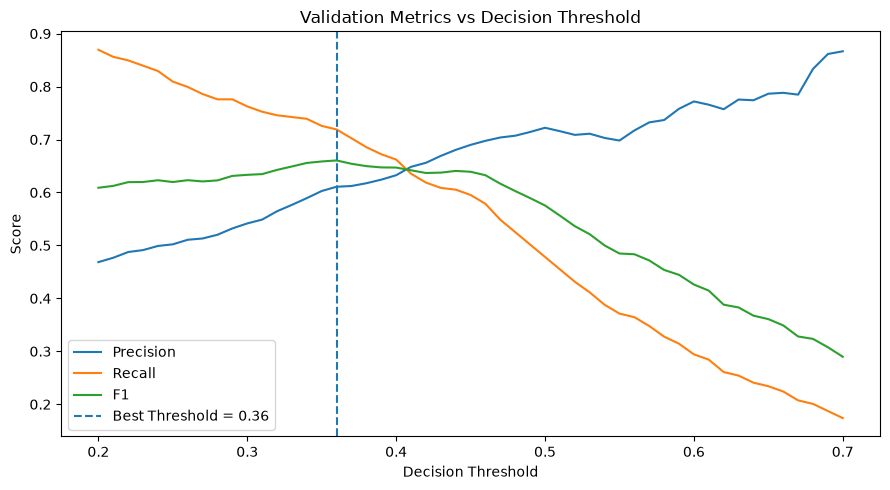

In [157]:
plt.figure(figsize=(9, 5))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1"],
    label="F1"
)

plt.axvline(
    best_threshold,
    linestyle="--",
    label=f"Best Threshold = {best_threshold:.2f}"
)

plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Validation Metrics vs Decision Threshold")

plt.legend()
plt.tight_layout()
plt.show()

In [158]:
y_test_prob = final_xgb.predict_proba(X_test)[:, 1]

In [159]:
y_test_pred = (
    y_test_prob >= best_threshold
).astype(int)

In [160]:
print(
    classification_report(
        y_test,
        y_test_pred,
        target_names=["No Churn", "Churn"]
    )
)

              precision    recall  f1-score   support

    No Churn       0.88      0.82      0.85      1035
       Churn       0.58      0.69      0.63       374

    accuracy                           0.78      1409
   macro avg       0.73      0.75      0.74      1409
weighted avg       0.80      0.78      0.79      1409



In [161]:
print(
    "ROC-AUC:",
    round(
        roc_auc_score(
            y_test,
            y_test_prob
        ),
        4
    )
)

print(
    "PR-AUC:",
    round(
        average_precision_score(
            y_test,
            y_test_prob
        ),
        4
    )
)

ROC-AUC: 0.8465
PR-AUC: 0.6558


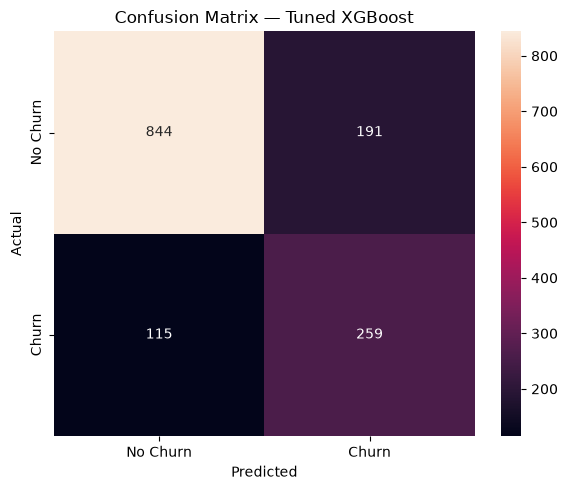

In [162]:
cm = confusion_matrix(
    y_test,
    y_test_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Tuned XGBoost")

plt.tight_layout()
plt.show()

In [163]:
final_catboost = catboost_search.best_estimator_

final_catboost.fit(
    X_train_final,
    y_train_final
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](27,)","['gender','SeniorCitizen','Partner',...,'HasSupport','HasSecurity', 'ChargePerTenureMonth']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,27
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='

In [164]:
y_val_prob_catboost = final_catboost.predict_proba(
    X_val
)[:, 1]

In [165]:
catboost_threshold_results = []

for threshold in thresholds:

    y_val_pred = (
        y_val_prob_catboost >= threshold
    ).astype(int)

    catboost_threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_val,
            y_val_pred
        ),
        "Recall": recall_score(
            y_val,
            y_val_pred
        ),
        "F1": f1_score(
            y_val,
            y_val_pred
        )
    })

catboost_threshold_df = pd.DataFrame(
    catboost_threshold_results
)

catboost_threshold_df.round(3)

,Threshold,Precision,Recall,F1
0,0.20,0.468,0.839,0.601
1,0.21,0.477,0.836,0.608
2,0.22,0.487,0.836,0.616
3,0.23,0.501,0.829,0.625
4,0.24,0.503,0.813,0.621
5,0.25,0.511,0.803,0.624
6,0.26,0.521,0.796,0.630
7,0.27,0.528,0.793,0.634
8,0.28,0.539,0.779,0.637
9,0.29,0.549,0.773,0.642


In [166]:
catboost_best_row = catboost_threshold_df.loc[
    catboost_threshold_df["F1"].idxmax()
]

catboost_best_row

Threshold    0.360000
Precision    0.613636
Recall       0.722408
F1           0.663594
Name: 16, dtype: float64

In [167]:
catboost_best_threshold = catboost_best_row["Threshold"]

print(
    "CatBoost threshold:",
    round(catboost_best_threshold, 2)
)

CatBoost threshold: 0.36


In [168]:
y_test_prob_catboost = final_catboost.predict_proba(
    X_test
)[:, 1]

y_test_pred_catboost = (
    y_test_prob_catboost >= catboost_best_threshold
).astype(int)

In [169]:
print(
    classification_report(
        y_test,
        y_test_pred_catboost,
        target_names=["No Churn", "Churn"]
    )
)

              precision    recall  f1-score   support

    No Churn       0.89      0.81      0.85      1035
       Churn       0.57      0.71      0.64       374

    accuracy                           0.78      1409
   macro avg       0.73      0.76      0.74      1409
weighted avg       0.80      0.78      0.79      1409



In [170]:
print(
    "CatBoost ROC-AUC:",
    round(
        roc_auc_score(
            y_test,
            y_test_prob_catboost
        ),
        4
    )
)

print(
    "CatBoost PR-AUC:",
    round(
        average_precision_score(
            y_test,
            y_test_prob_catboost
        ),
        4
    )
)

CatBoost ROC-AUC: 0.8461
CatBoost PR-AUC: 0.6648


In [171]:
final_gb = gb_search.best_estimator_

final_gb.fit(
    X_train_final,
    y_train_final
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](27,)","['gender','SeniorCitizen','Partner',...,'HasSupport','HasSecurity', 'ChargePerTenureMonth']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,27
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='

In [172]:
y_val_prob_gb = final_gb.predict_proba(
    X_val
)[:, 1]

In [173]:
gb_threshold_results = []

for threshold in thresholds:

    y_val_pred = (
        y_val_prob_gb >= threshold
    ).astype(int)

    gb_threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_val,
            y_val_pred
        ),
        "Recall": recall_score(
            y_val,
            y_val_pred
        ),
        "F1": f1_score(
            y_val,
            y_val_pred
        )
    })

gb_threshold_df = pd.DataFrame(
    gb_threshold_results
)

gb_threshold_df.round(3)

,Threshold,Precision,Recall,F1
0,0.20,0.481,0.836,0.611
1,0.21,0.491,0.826,0.616
2,0.22,0.502,0.826,0.625
3,0.23,0.506,0.816,0.625
4,0.24,0.507,0.806,0.623
5,0.25,0.511,0.799,0.623
6,0.26,0.518,0.789,0.625
7,0.27,0.523,0.783,0.627
8,0.28,0.533,0.779,0.633
9,0.29,0.546,0.769,0.639


In [174]:
gb_best_row = gb_threshold_df.loc[
    gb_threshold_df["F1"].idxmax()
]

gb_best_row

Threshold    0.400000
Precision    0.646302
Recall       0.672241
F1           0.659016
Name: 20, dtype: float64

In [175]:
gb_best_threshold = gb_best_row["Threshold"]

print(
    "Gradient Boosting threshold:",
    round(gb_best_threshold, 2)
)

Gradient Boosting threshold: 0.4


In [176]:
y_test_prob_gb = final_gb.predict_proba(
    X_test
)[:, 1]

y_test_pred_gb = (
    y_test_prob_gb >= gb_best_threshold
).astype(int)

In [177]:
print(
    classification_report(
        y_test,
        y_test_pred_gb,
        target_names=["No Churn", "Churn"]
    )
)

              precision    recall  f1-score   support

    No Churn       0.86      0.84      0.85      1035
       Churn       0.59      0.64      0.61       374

    accuracy                           0.79      1409
   macro avg       0.73      0.74      0.73      1409
weighted avg       0.79      0.79      0.79      1409



In [178]:
print(
    "Gradient Boosting ROC-AUC:",
    round(
        roc_auc_score(
            y_test,
            y_test_prob_gb
        ),
        4
    )
)

print(
    "Gradient Boosting PR-AUC:",
    round(
        average_precision_score(
            y_test,
            y_test_prob_gb
        ),
        4
    )
)

Gradient Boosting ROC-AUC: 0.8454
Gradient Boosting PR-AUC: 0.6631


In [179]:
final_model_results = [
    {
        "Model": "Tuned XGBoost",
        "Threshold": best_threshold,
        "Precision": precision_score(
            y_test,
            y_test_pred
        ),
        "Recall": recall_score(
            y_test,
            y_test_pred
        ),
        "F1": f1_score(
            y_test,
            y_test_pred
        ),
        "ROC-AUC": roc_auc_score(
            y_test,
            y_test_prob
        ),
        "PR-AUC": average_precision_score(
            y_test,
            y_test_prob
        )
    },
    {
        "Model": "Tuned CatBoost",
        "Threshold": catboost_best_threshold,
        "Precision": precision_score(
            y_test,
            y_test_pred_catboost
        ),
        "Recall": recall_score(
            y_test,
            y_test_pred_catboost
        ),
        "F1": f1_score(
            y_test,
            y_test_pred_catboost
        ),
        "ROC-AUC": roc_auc_score(
            y_test,
            y_test_prob_catboost
        ),
        "PR-AUC": average_precision_score(
            y_test,
            y_test_prob_catboost
        )
    },
    {
        "Model": "Tuned Gradient Boosting",
        "Threshold": gb_best_threshold,
        "Precision": precision_score(
            y_test,
            y_test_pred_gb
        ),
        "Recall": recall_score(
            y_test,
            y_test_pred_gb
        ),
        "F1": f1_score(
            y_test,
            y_test_pred_gb
        ),
        "ROC-AUC": roc_auc_score(
            y_test,
            y_test_prob_gb
        ),
        "PR-AUC": average_precision_score(
            y_test,
            y_test_prob_gb
        )
    }
]

final_model_results_df = pd.DataFrame(
    final_model_results
)

final_model_results_df.sort_values(
    "PR-AUC",
    ascending=False
).round(4)

,Model,Threshold,Precision,Recall,F1,ROC-AUC,PR-AUC
1,Tuned CatBoost,0.36,0.5745,0.7112,0.6356,0.8461,0.6648
2,Tuned Gradient Boosting,0.40,0.5906,0.6364,0.6126,0.8454,0.6631
0,Tuned XGBoost,0.36,0.5756,0.6925,0.6286,0.8465,0.6558
